In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:6]:

#   print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(context, '--->', ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([42, 3]), torch.int64, torch.Size([42]), torch.int64)

In [7]:
C = torch.randn((27, 2))

In [8]:
emb = C[X]
emb.shape

torch.Size([42, 3, 2])

In [9]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [93]:
# For operation emb @ W1 + b1
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape
torch.cat(torch.unbind(emb, 1), 1).shape
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)
emb.view(32, 6) @ W1 + b1
emb.view(emb.shape[0], 6) @ W1 + b1
emb.view(-1, 6) @ W1 + b1

tensor([[-3.3727, -2.1343,  1.8849,  ..., -2.9776, -3.4273, -4.2018],
        [-4.2906, -0.6684, -1.6449,  ...,  0.5152, -6.5889, -2.0010],
        [-6.6221,  1.6038,  1.3361,  ..., -5.1293, -0.4618,  4.8277],
        ...,
        [-4.1088,  0.8022,  1.1312,  ..., -3.5127, -0.0546,  1.4924],
        [ 1.5259, -1.8859,  0.5213,  ...,  0.1068,  1.7705, -3.1892],
        [ 1.5142, -0.6017, -2.1244,  ..., -2.4967, -2.3944, -0.7966]])

In [10]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

torch.Size([42, 100])

In [11]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [12]:
logits = h @ W2 + b2
logits.shape

torch.Size([42, 27])

In [13]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([42, 27])

In [15]:
# torch.arrange(32)
# Y
# prob[torch.arange(32), Y]
# prob[torch.arange(32), Y].log().mean()
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(15.3572)

In [ ]:
# ------------ now made respectable :) --------------- Temp with 5 words

In [16]:
X.shape, Y.shape # dataset

(torch.Size([42, 3]), torch.Size([42]))

In [17]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [18]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [ ]:
emb = C[X] # embed the characters into vectors (X.shape[0], 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer (X.shape[0], 100)
logits = h @ W2 + b2 # output layer (X.shape[0], 27)
counts = logits.exp() # counts (X.shape[0], 27)
prob = counts / counts.sum(1, keepdims=True) # probabilities for next character (X.shape[0], 27)
loss = -prob[torch.arange(X.shape[0]), Y].log().mean() # loss function (scalar)
loss

tensor(17.7697)

In [19]:
# High values of exponential can cause values like inf, so we use cross_entropy function
# cross entropy function decreases the range by the highest number in the logits
# so that the highest number becomes 0 and all other numbers become negative, gives same result
F.cross_entropy(logits, Y) # intead of counts, prob and loss, we can do it in one go with this function

tensor(15.3572)

In [20]:
for p in parameters:
    p.requires_grad = True

In [21]:
for _ in range(10000):
    # forward pass
    emb = C[X] # embed the characters into vectors (X.shape[0], 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer (X.shape[0], 100)
    logits = h @ W2 + b2 # output layer (X.shape[0], 27)
    loss = F.cross_entropy(logits, Y) # loss function (scalar)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update    
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

# This will produce a smaller loss because we are over-fitting to a small dataset.

0.2565123438835144


In [ ]:
# ------------ now made respectable :) --------------- With all the words

In [22]:
# build the dataset with all words

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

#   print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(context, '--->', ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [23]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [24]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [25]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [26]:
for _ in range(100):
    # forward pass
    emb = C[X] # embed the characters into vectors (X.shape[0], 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer (X.shape[0], 100)
    logits = h @ W2 + b2 # output layer (X.shape[0], 27)
    loss = F.cross_entropy(logits, Y) # loss function (scalar)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update    
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

3.589250087738037


In [ ]:
# Now to make it faster, we can use mini-batches instead of the whole dataset.

In [27]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [28]:
for _ in range(1000):
    # mini-batch construct
    ix = torch.randint(0, X.shape[0], (32,)) # 32 random indices from the dataset 

    # forward pass
    emb = C[X[ix]] # embed the characters into vectors (X.shape[0], 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer (X.shape[0], 100)
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Y[ix]) # loss function (scalar)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update    
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

2.736860990524292


In [29]:
emb = C[X] 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss.item()

2.7070658206939697

In [ ]:
# Now lets optimize the use of learning rate
# By checking the loss after some checks, learning rate seems to between -1 and -0.001

In [30]:
# build the dataset with all words

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

#   print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(context, '--->', ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [31]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [32]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [33]:
lri = []
lossi = []

for i in range(1000):
    # mini-batch construct
    ix = torch.randint(0, X.shape[0], (32,)) # 32 random indices from the dataset 

    # forward pass
    emb = C[X[ix]] # embed the characters into vectors (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer (32, 100)
    logits = h @ W2 + b2 # output layer (32, 27)
    loss = F.cross_entropy(logits, Y[ix]) # loss function (scalar)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update    
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

9.159602165222168


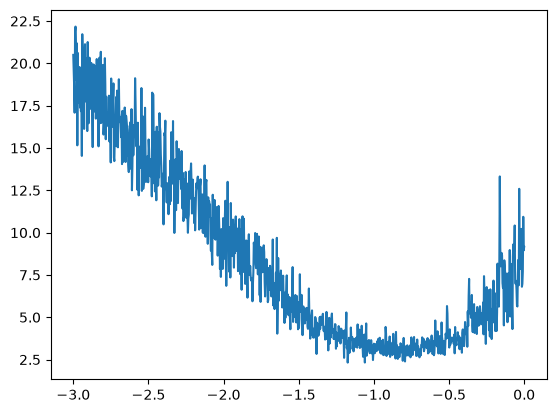

In [34]:
plt.plot(lri, lossi)

In [ ]:
# This shows that optimum learning rate is -0.1

In [35]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [46]:
# Use the learning rate of -0.1 and learning rate decay rate of -0.01
for i in range(40000):
    # mini-batch construct
    ix = torch.randint(0, X.shape[0], (32,)) # 32 random indices from the dataset 

    # forward pass
    emb = C[X[ix]] # embed the characters into vectors (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer (32, 100)
    logits = h @ W2 + b2 # output layer (32, 27)
    loss = F.cross_entropy(logits, Y[ix]) # loss function (scalar)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update    
    for p in parameters:
        p.data += -0.01 * p.grad

# print(loss.item())

In [47]:
emb = C[X] 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss.item()

2.253101110458374

In [ ]:
# In practice, we want to find a decent learning rate using the above approach and the train for 
# for a while until it platues. Then do a learning rate decay to get a better loss which is like 
# reducing the learning rate by a factor of 10 so that we get a better loss.

In [ ]:
# Training split - Train parameters 
# Development split - Train hyper parameters eg size of hidden layer, size of embedding
# Test split - Evaluate model performance
# 80% of the data is used for training, 10% for development and 10% for testing.

In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [ ]:
# Use the learning rate of -0.1 and learning rate decay rate of -0.01
for i in range(40000):
    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (32,)) # 32 random indices from the dataset 

    # forward pass
    emb = C[Xtr[ix]] # embed the characters into vectors (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # hidden layer (32, 200)
    logits = h @ W2 + b2 # output layer (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # loss function (scalar)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update    
    for p in parameters:
        p.data += -0.01 * p.grad

In [ ]:
# If training and dev loss are equal, then its called under fitting.
# This usually means that the model is too simple to capture the complexity of the data.
# In such cases, we can try increasing the number of neurons in each layer.
# or we can try increasing the batch size.
# Once training and dev losses start to depart, then we can say that model is overfitting.
# For training the model, lets say over 200k iterations,
# For 1st 100k iterations, use a leraning rate of -0.1
# For next 100k iterations, use a learning rate of -0.01

In [17]:
# Loss on training set
emb = C[Xtr] 
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.112828493118286

In [18]:
# Loss on dev set
emb = C[Xdev] 
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.1584835052490234

In [ ]:
# Works when you have only 2 dimensions in the embedding matrix C.
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [22]:
# sample from the model
g = torch.Generator().manual_seed(214747568753647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

rivedlynn.
chrishon.
naj.
cree.
eotyn.
detteri.
croya.
ruansabrij.
mis.
reyanna.
quella.
chl.
micon.
zavayah.
moa.
cadarande.
blinah.
kamarkiyah.
jaqhea.
jayson.
